<a href="https://colab.research.google.com/github/arnoldvialfont/langage_et_iag/blob/master/3_les_modeles_de_langage_et_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<br><div align="center"><span style="font-size:200%;font-weight:bold">Les modèles de langage et les Transformers</span></div></br>

<div align="center"><span style="font-size:150%"> Arnold Vialfont, UPEC - ERUDITE, UNIL </span></div>


<br>


<div align="center"><span style="font-size:130%">  Avril 2026</span></div>

***

Ce notebook présente les modèles de langage et les Transformers, qui sont issus des architectures de réseaux de neurones utilisées pour traiter le langage naturel. LInitialement, les modèles de langage sont conçus pour prédire la probabilité d'une séquence de mots, mais les les Transformers sont une architecture spécifique qui utilise des mécanismes d'attention pour capturer les relations entre les mots dans une séquence.

Pour aborder ce sujets, nous allons commencer par revenir sur l'hypothèse d'indépendance des tokens dans les méthodes de vectorisation présentées dans le notebook précédent, et introduire les notions d'embeddings et de contexte qui sont à la base des modèles de langage et des Transformers.

Sommaire de ce notebook :

- **Embeddings et contexte**
    - Plongement de mots dans une espace sémantique
    - Contexte d'un mot et *self-attention*
    - Apprentissage de l'instruction

- **La librairie Transformers**
    - Tour d'horizon de la librairie Transformers
    - Entrainement d'un classifieur de sentiment

# 1. Embeddings et contexte

L'objectif de cette section est de présenter les concepts menant à la **construction d'un espace sémantique** où peuvent être distribués les mots et donc les documents, c'est-à-dire de résumer leurs sens à des coordonnées qui révèlent leurs proximités relatives.

Une première série de travaux a permis de construire des vecteurs pour représenter les instances des mots du langage naturel (**embedding**), à partir de nombreux exemples de textes disponibles sur Internet, les réseaux sociaux, livres numérisés, etc. Une seconde série de travaux, plus récents, a poursuivi cette direction en faisant dépendre la construction des vecteurs de mot en fonction de leur **contexte** dans un document, rendant le sens des mots plus *fluide*.

On ne peut que survoler ici les méthodes mobilisées pour réaliser ces travaux, et renvoyer par exemple à Smith (2020) pour une présentation non technique mais détaillée du passage de l'encodage one-hot à l'embedding avec contexte. Cependant, les intuitions peuvent être présentées ici puis une illustration avec `SpaCy`. C'est à ce stade qu'il est généralement souhaitable de passer sur des système avec des GPU et avec une interface où les installations sont simplifiées, comme Google Colab.

## 1.1 Les mots comme vecteurs sémantiques

Le recours aux **embeddings** se fait à deux niveaux :
- le *word embedding* (en français plongement de mot ou lexical) correspond à l'association des mots d'un corpus à des vecteurs provenant d'une représentation distribuée du langage ou du corpus lui-même. Chaque mot est remplacé par un vecteur d'une dimension fixée (de [25 parmi les modèles les plus petits de GloVe de Stanford](https://nlp.stanford.edu/projects/glove/) jusqu'à, par exemple, [12 288 pour le modèle `Davinci` d'OpenAI](https://platform.openai.com/docs/guides/embeddings/second-generation-models)). L'objectif est de **construire une distribution des mots en  tenant compte de leurs substituabilité et relation**. Par exemple, on souhaite pouvoir réaliser une opération de la forme :

$$
king - man + woman \simeq queen,\text{ } walked - walking + swimming \simeq swam, \text{ ou } Spain - Madrid + Berlin \simeq Germany.
$$

<div>
<div align="center" style="margin-top:0.5cm"> <b> <b> Dimensions semantiques (<a href=https://developers.google.com/machine-learning/crash-course/embeddings/translating-to-a-lower-dimensional-space?hl=fr>image issue de developers.google.com</a>)</b></b><br>
<img src="https://github.com/arnoldvialfont/langage_et_iag/blob/master/img/word_embedding.png?raw=1" style="margin-bottom:0.5cm;width:80%"></div>
</div>   





- le *doc embedding* (plongement de document) correspond à la distribution des documents dans une représentation distribuée du langage ou du corpus lui-même. Il peut consister par exemple au calcul de la moyenne des composantes des vecteurs associés aux plongement des mots (et est de même dimension dans ce cas).

### 1.1.1 Construction des embeddings

Un des premiers modèles entrainés dans cette direction est [word2vec](https://code.google.com/archive/p/word2vec/), créé par des chercheurs de Google (Mikolov et al., 2013). La présentation des méthodes sous-jacentes à son entrainement permet de se faire une idée pour les différentes techniques d'embeddings. Il existe en fait deux variantes pour l'entrainement de word2vec  :

- Continuous bag of words (CBOW) : on cherche à prédire le mot au centre d'une séquence ou "contexte" donné (par un réseau de neurones). On a donc ici l'idée de la construction d'un modèle probabiliste du langage de gauche et de droite vers un mot au centre du contexte.
<div>
<div align="center" style="margin-top:0.5cm"> <b> Pour un contexte, prédiction du mot au centre (Vajjala et al., 2020, p.98)</b><br>
<img src="https://github.com/arnoldvialfont/langage_et_iag/blob/master/img/embedding_cbow.png?raw=1" style="margin-bottom:0.5cm;width:70%"></div>
</div>   


- Skip-gram : on cherche à prédire le contexte à partir d'un mot donné en son centre. L'opération est donc à l'opposé de CBOW et implique la prédiction de plusieurs mots à partir d'un seul, situés à gauche et à droite de celui-ci (par réseau de neurones).
<div>
<div align="center" style="margin-top:0.5cm"> <b> Pour un mot au centre, prédiction du contexte (Vajjala et al., 2020, p.101)</b><br>
<img src="https://github.com/arnoldvialfont/langage_et_iag/blob/master/img/embedding_skipg.png?raw=1" style="margin-top:0.5cm;margin-bottom:0.5cm;width:60%"></div>
</div>


Dans les deux cas, à partir de textes non labélisés en eux-mêmes, on réalise un **apprentissage supervisé** où chaque mot devient à alternativement un exemple ou un label. Les **premiers hyperparamètres** des algorithmes sont alors :

- la **taille de la fenêtre du contexte** considéré : la prédiction d'un grand contexte est plus compliquée mais permet de capter davantage d'information pour la vectorisation des mots (et documents),

- la **dimension des vecteurs** qui est celle de l'espace des embeddings : une dimension supérieure permet de meilleures prédictions mais demande plus d'exemples pour l'entrainement et génère une modèle plus volumineux (en termes de stockage et de RAM lors de la manipulation).


Dans la figure ci-dessous, [issue de Rong (2016)](https://arxiv.org/pdf/1411.2738.pdf), on trouve les deux réseaux de neurones des apprentissages de word2vec. Pour un contexte de taille $C$, ils reposent tous deux sur une unique couche de $N$ neurones (dimension des vecteurs du plongement) et utilisent en entrées et sorties des vecteurs binaires d'une taille égale à celle du vocabulaire $V$ (encoding one-hot mais où chaque vecteur contient un seul 1 et le reste de 0). **Dans CBOW** (à gauche), pour un exemple $k$, les vecteurs des mots du vocabulaire présents dans le contexte sont encodés par les $x_{ck}$ avec $c \in \{1, 2, ..., C\}$ et $y_j$ est le vecteur qui identifie le mot du vocabulaire situé au centre du contexte. **Dans Skip-gram** (à droite), c'est l'inverse : chaque mot au centre d'un exemple est encodé par $x_k$ qui est associé aux occurrences des mots du contexte, encodées par les $y_{cj}$. Dans chaque étape d'entrainement, les poids du réseau de neurones sont ajustés dans un objectif de minimisation des erreurs entre la (les) prédiction(s) du modèle et le(s) mot(s) effectivement observé(s) en sortie. Après entrainement, c'est la matrice $W$ de taille $V \times N$ qui contient le plongement des mots du vocabulaire : chacune de ses lignes est la coordonnée d'un mot dans l'espace sémantique créé à partir du corpus.

<div>
<div align="center" style="margin-top:0.5cm"> <b> Modèles d'entrainement de word2vec : CBOW vs Skip-Gram (Rong, 2016)</b><br>
<img src="https://github.com/arnoldvialfont/langage_et_iag/blob/master/img/CBOW_Skip-gram.png?raw=1" style="margin-bottom:0.5cm;width:80%"></div>
</div>   

Entre ces deux modèles, selon leurs auteurs, **CBOW est plus rapide à entrainer et est plus efficace pour les tâches syntaxiques, mais moins pour les tâches sémantiques**. Par ailleurs, Skip-gram fonctionne bien avec des petits datasets et représente mieux les mots peu fréquents dans le corpus.

D'autres embeddings populaires sont [GloVe développé par Stanford](https://nlp.stanford.edu/projects/glove/) et [fastText développé par Facebook](https://fasttext.cc/docs/en/english-vectors.html).  Il est à noter que `fastText` a pour particularité de réaliser le **word embedding par sous-mots**, c'est-à-dire qu'ils sont découpés comme s'ils étaient toujours composés de préfixes et suffixes. Cela évite de rencontrer en suite le problème des termes hors vocabulaire (*out of vocabulary* ou OOV en anglais) : dans la phase opérationnelle on peut conserver les mots absents du corpus d'entrainement, notament les fautes d'orthographe, jargon, etc.

<div class="alert alert-danger">
<b> Attention :</b> Deux remaques sont nécessaires ici, bien que valables pour plusieurs des méthodes du machine learning et transfer learning :

- L'entrainement des embeddings doit se faire sur un très grand corpus pour obtenir des résultats (i.e. des vecteurs de mots) satisfaisants. Autant que possible, on utilise des algorithmes pré-entrainés plutôt que de faire un entrainement "from scratch" car leur construction est très coûteuse en termes de temps et de dépenses, notamment énergétiques. Sur les liens entre numérique et environnement, <a href=https://www.inria.fr/fr/numerique-progres-durable-environnement-pour-la-science>voir notamment ce dossier de l'INRIA (2023)</a>.
    
    
- Il est important de garder à l'esprit que les espaces sémantiques construits sont dépendants des exemples fournis à l'algorithme. Il est donc nécessaire d'être attentif aux éventuels biais issus du corpus utilisé pour l'entrainement car celui-ci peut se répercuter dans les résultats de l'algorithme en fin de pipeline. Par exemple, Bolukbasi et al. (2016) fait état d'un biais genré dans l'embedding de word2vec réalisé à partir du corpus Google News.
</div>

### 1.1.2 Exploration d'un plongement avec SpaCy

`Spacy` permet d'obtenir la **distribution des mots ou documents d'un modèle téléchargé** en utilisant la méthode `.vector`.

- Par exemple, dans le cas du modèle `fr_core_news_lg`, les vecteurs des mots sont de dimension $N = 300$ :

In [ ]:
import spacy

nlp = spacy.load('fr_core_news_lg')

french_sent = "Le traitement automatique du langage naturel (abr. taln), ou traitement automatique de la langue naturelle, ou encore traitement automatique des langues (abr. TAL) est un domaine multidisciplinaire impliquant la linguistique, l'informatique et l'intelligence artificielle, qui vise à créer des outils de traitement de la langue naturelle pour diverses applications."

doc_spacy1 = nlp(french_sent)


In [ ]:
n=10

token=doc_spacy1[0]

print('Dans la phrase :', doc_spacy1)

print("\nLes {} premières valeurs du vecteur de '{}' (sur {}) sont :".format(n, token, len(token.vector)))

doc_spacy1[0].vector[:n]

Dans la phrase : Le traitement automatique du langage naturel (abr. taln), ou traitement automatique de la langue naturelle, ou encore traitement automatique des langues (abr. TAL) est un domaine multidisciplinaire impliquant la linguistique, l'informatique et l'intelligence artificielle, qui vise à créer des outils de traitement de la langue naturelle pour diverses applications.

Les 10 premières valeurs du vecteur de 'Le' (sur 300) sont :


array([  1.1956,  -1.0795,  -4.2383,   4.0183, -12.174 ,  -7.5653,
         1.7154,   3.882 ,  -5.2665,   3.8679], dtype=float32)

- Si on applique la même méthode à l'ensemble du document, on obtient le vecteur du texte dans son ensemble :

In [ ]:
import numpy as np

print("Pour la phrase '{}' les {} premières valeurs du vecteur sont : \n".format(doc_spacy1, n))

print(' ', doc_spacy1.vector[:n],'\n')

test_vecteurs = all(doc_spacy1.vector == np.mean([token.vector for token in doc_spacy1], axis=0))

print("On peut vérifier que ce vecteur est simplement la moyenne composante par composante des vecteurs des mots :", test_vecteurs, '\n')

for token in doc_spacy1:

    print(' ', token.text, ' : ', token.vector[:n],'\n')

Pour la phrase 'Le traitement automatique du langage naturel (abr. taln), ou traitement automatique de la langue naturelle, ou encore traitement automatique des langues (abr. TAL) est un domaine multidisciplinaire impliquant la linguistique, l'informatique et l'intelligence artificielle, qui vise à créer des outils de traitement de la langue naturelle pour diverses applications.' les 10 premières valeurs du vecteur sont : 

  [-0.141067   -0.5815762  -0.36667952  2.3468244  -2.9342043   1.0479932
 -0.19829097  0.5639371   1.0234935   0.5345997 ] 

On peut vérifier que ce vecteur est simplement la moyenne composante par composante des vecteurs des mots : True 

  Le  :  [  1.1956  -1.0795  -4.2383   4.0183 -12.174   -7.5653   1.7154   3.882
  -5.2665   3.8679] 

  traitement  :  [ 2.1765  -0.50469 -1.4302   1.9958  -3.0893  -0.67525  1.5347   2.457
  1.4264  -0.24864] 

  automatique  :  [ 0.40773  0.22671 -1.7505   2.5688  -2.6987   1.6818  -0.82223  0.17542
  1.1271  -0.20474] 

  du 

- Si le modèle chargé ne se termine pas par `sm` (i.e. n'est pas la version *small* de la langue), on peut avoir accès à son vocabulaire par la méthode `.vocab`. Dans ce cas, on a accès à la [méthode `.most_similar`](https://spacy.io/api/vectors#most_similar) pour trouver les mots les plus proches d'un autre :

In [ ]:
mot_fr = 'roi'

ms = 10

print('Pour le mot :', mot_fr)

nlp_fr_lg = spacy.load('fr_core_news_lg')

vec_spacy = nlp_fr_lg.vocab[mot_fr].vector

result = nlp_fr_lg.vocab.vectors.most_similar(vec_spacy.reshape(1,-1), # il faut une matrice : np.array([1,2,3]).reshape(1,-1) = np.array([[1,2,3]])
                                              n=ms)

words = [nlp_fr_lg.vocab[i].text for i in result[0][0]]

print(f'\nLes {ms} mots les plus proches sont : \n\n', words[1:]) #La méthode renvoie en premier le mot donc on enlève words[0]

Pour le mot : roi

Les 10 mots les plus proches sont : 

 ['Roi', 'prince', 'monarque', 'empereur', 'régent', 'Empereur', 'suzerain', 'coempereur', 'l\x92empereur']


- On peut considérer des opérations simples :

In [ ]:
# ATTNETION : les opérations sur les vecteurs modifie l'encodage des futurs mots (donc rechargement du modèle nécessaire)

nlp_fr_lg = spacy.load('fr_core_news_lg')

words_list = [('roi', 'homme', 'femme'),

              ('marchant', 'marcha', 'nagea'),

              ('Espagne', 'Madrid', 'Berlin'),
]

for word_triple in words_list :

    vec_spacy1 = nlp_fr_lg.vocab[word_triple[0]].vector

    vec_spacy2 = nlp_fr_lg.vocab[word_triple[1]].vector

    vec_spacy3 = nlp_fr_lg.vocab[word_triple[2]].vector

    vec_spacy4 = vec_spacy1 - vec_spacy2 + vec_spacy3

    result4 = nlp_fr_lg.vocab.vectors.most_similar(vec_spacy4.reshape(1,-1), n=ms)

    words4 = [nlp_fr_lg.vocab[j].text for j in result4[0][0]]

    print(f"\n- L'opération '{word_triple[0]}' - '{word_triple[1]}' + '{word_triple[2]}' donne : '{words4[1]}'.")


- L'opération 'roi' - 'homme' + 'femme' donne : 'reine'.

- L'opération 'marchant' - 'marcha' + 'nagea' donne : 'nageant'.

- L'opération 'Espagne' - 'Madrid' + 'Berlin' donne : 'Allemagne-'.


- En étudiant les proximités des vecteurs associés aux documents, on peut assez simplement mesurer une forme de degré de similitude sémantique (avec la méthode `cosine` de `scipy`) :

In [ ]:
from scipy.spatial.distance import cosine

In [ ]:
nlp_fr_sm = spacy.load("fr_core_news_sm") #17.2Mo
documents = ["j'aime la peinture", "je fais du basketball", "j'aime le basketball"]
v1 = nlp_fr_sm(documents[0]).vector.reshape(-1)
v2 = nlp_fr_sm(documents[1]).vector.reshape(-1)
v3 = nlp_fr_sm(documents[2]).vector.reshape(-1)

print('distance v1-v2 :',cosine(v1,v2))
print('distance v1-v3 :',cosine(v1,v3))
print('distance v2-v3 :',cosine(v2,v3))

distance v1-v2 : 0.8792344458490071
distance v1-v3 : 0.4160088552341489
distance v2-v3 : 0.438834905338943


On peut cependant noter que les résultats peuvent différer d'une langue à l'autre si les modèles ne sont pas entrainés de la même manière :

In [ ]:
nlp_en_sm = spacy.load("en_core_web_sm") #13.7Mo
documents = ["i like painting", "i do basketball", "i like basketball"]
v1 = nlp_en_sm(documents[0]).vector.reshape(-1)
v2 = nlp_en_sm(documents[1]).vector.reshape(-1)
v3 = nlp_en_sm(documents[2]).vector.reshape(-1)

print('distance v1-v2 :',cosine(v1,v2))
print('distance v1-v3 :',cosine(v1,v3))
print('distance v2-v3 :',cosine(v2,v3))

distance v1-v2 : 0.5467276891771293
distance v1-v3 : 0.25364554812522266
distance v2-v3 : 0.3545675817548062


<div class="alert alert-info">
<b> Info :</b> <code>SpaCy</code> ne permet pas de réaliser l'entrainement d'un embedding (voir <code>gensim</code> et <code>fastText</code> si besoin). Cependant, <a href=https://spacy.io/usage/linguistic-features#vectors-similarity>des vecteurs tiers peuvent être importés</a>, par exemple les vecteurs de <code>fastText</code> qui pesent 5.6 Go pour le français et sont disponibles <a href=https://fasttext.cc/docs/en/pretrained-vectors.html>sur le site du package (`bin+txt`)</a>. <code>gensim</code> offre la même possibilité avec la méthode <code>KeyedVectors.load_word2vec_format</code>.
</div>

## 1.2 Les vecteurs de mots en fonction du contexte

Pour construire un modèle de langage efficace, il faut intégrer le fait que **le sens d'un mot dépend de son contexte**. En effet, représenter les mots d'un texte à l'aide d'un nombre entier ou d'un vecteur fixe n'est pas cohérent avec la réalité : il faut que le vecteur qui représente un mot change selon le contexte de ce dernier. [Ce n'est pas le cas dans la plupart des modèles de `SpaCy`](https://spacy.io/usage/linguistic-features#similarity-expectations) : par exemple, quel que soit le contexte du mot 'orange', la méthode `.most_similar` appliquée à son vecteur renvoie toujours 'orangeade', 'orangé' puis 'jaune' dans `fr_core_news_lg`.

Une des premières approches pour construire des vecteurs de documents qui ne soient pas uniquement l'agrégation de ceux des mots le constituant est **doc2vec**, présenté par deux chercheurs de Google dans Le et Mikolov (2014). L'entrainement y est semblable à celui vu pour word2vec, avec en plus une couche de neurones associée au niveau des documents, paragraphes ou phrases (selon les besoins du cas d'usage). Cependant, c'est **ELMo** (pour *embeddings from language models*) présenté par des chercheurs de [Allen Insitute for AI](https://allenai.org/allennlp/software/elmo) dans Peters et al. (2018) qui est considéré comme l'avancée la plus significative dans la prise en compte du contexte pour la construction des vecteurs de mots. Cette deuxième approche modifie les vecteurs des mots en fonction de leurs séquences ([à l'aide de réseaux LSTM](https://medium.com/@RobinVetsch/nlp-from-word-embedding-to-transformers-76ae124e6281)).

Ici, nous nous limitons à présenter les solutions basées sur les **Transformers** qui reposent sur le concept de "*self-attention*" présenté par des chercheurs de Google dans Vaswani et al. (2017). Cette méthode est à la base des modèles SOTA du NLP et est moins coûteuse à mettre en oeuvre que celles basées sur des réseaux de neurones récurrents.

<div class="alert alert-info">
<b> Info :</b> Certains modèles de <code>SpaCy</code> implémentent les Transformers, <a href=https://spacy.io/models/fr#fr_dep_news_trf>par exemple <code>fr_dep_news_trf</code></a>. Cependant, ces modèles contiennent souvent moins de fonctionnalités que les versions <code>lg</code> (par exemple pas de NER en français) et les embeddings ne sont pas toujours simples à obtenir. On passe alors à la librairie <code>transformers</code>.
</div>

L'architecture originale des Transformers implique la qualification de modèle **seq2seq** ou encore *encodeur-décodeur*, car elle est orientée vers la traduction de phrases d'une langue vers une autre. Cependant, certains modèles Transformers sont qualifiés d'encodeurs, dont **BERT** issu de Devlin et al (2019), et d'autres de décodeurs, dont **GPT** issu de Radford et  al. (2018). Bien que cette catégorisation soit parfois un peu simplificatrice, la figure suivante illustre la répartition de certains des principaux modèles entre ces deux catégories et leurs liens de parentés.

<div>
<div align="center" style="margin-top:0.6cm"> <b> Transformers Tree Of Life (Tunstall et al., 2022, p. 79)</b><br>
<img src="https://github.com/arnoldvialfont/langage_et_iag/blob/master/img/transformers-zoo-compact.png?raw=1" style="margin-bottom:0.5cm;width:50%"></div>
</div>   

Pour présenter l'**embeddings des mots en fonction de leur contexte**, on va principalement se focaliser ici sur **la partie encoder**. La figure suivante illustre la structure globale en deux blocs, où on trouve en entrée de l'encodeur les mots "Transfomers are great !" et "Transformers sind grossartig !" en sortie du décodeur. Dans les deux blocs, on observe alors deux éléments communs : une **partie d'attention** qui relie chaque mot (*son embedding initial à l'entrée de l'encodeur*) à un **empilement de réseaux de neurones feed-forward** qui exploitent chacun un mot (*son embedding contextualisé dans l'encodeur*). Les états cachés ("*hiddens states*") entre les deux blocs sont les messages emis par chaque FFNN de l'encodeur et interprétés par le décodeur.

<div>
<div align="center" style="margin-top:0.5cm"> <b> Architecture initiale des Transformers (Tunstall et al., 2022, p. 6)</b><br>
<img src="https://github.com/arnoldvialfont/langage_et_iag/blob/master/img/transformers-initial-archi.png?raw=1" style="margin-bottom:0.5cm;width:80%"></div>
</div>

C'est la partie d'attention, ou plus exactement de **self-attention**, de l'encodeur qui est la plus intéressante ici car c'est elle qui réalise la "mise à jour" (*update*) des embeddings des mots selon leur contexte. L'idée principale derrière cette notion est de transformer chaque embedding en faisant la moyenne pondérée des embbeddings de la séquence. Ainsi, en notant $x_1, x_2, ..., x_n$ les vecteurs du plongement initial de $n$ token, les vecteurs du plongement contextualisé, notés $x'_1, x'_2, ..., x'_n$ seront la combinaison linéaire de tous les vecteurs initiaux :

$$x'_i = w_{1i} x_1 + w_{2i} x_2 + ... + w_{ni} x_n,$$

pour tout token $i \in \{1, 2, ..., n\}$ et où chaque $w_{ji}$ avec $j \in \{1, 2, ..., n\}$ est un "*degrés d'attention*" (ou poids) reliant le token $j$ au token $i$.

Il est à noter que **les degrés d'attention $w_{ji}$ représentent les importances des mises à jour contextuelle entre les tokens $i$ et $j$**. Ils sont eux-mêmes calculés à partir des vecteurs intiaux des $i$ et $j$, altérés par des *poids qui sont ajustés durant l'apprentissage*. Par exemple, une méthode commune, appelée **scaled dot-product attention**, considère en première mesure de proximité un produit scalaire des embeddings ($\simeq x_i \cdot x_j$). La figure suivante illuste les $w_{ij}$ pour un même mot dans deux contextes différents puis, en dessous, le détail du produit scalaire réalisé par le modèle BERT (une fois entrainé) dans le premier contexte "time flies like an arrow".

<div align="center" style="margin-top:0.5cm"> <b> Poids d'attention issus du modèle BERT de deux phrases (<a href=https://github.com/jessevig/bertviz>visualisés avec BertViz</a>)</b><br>

<img src="https://github.com/arnoldvialfont/langage_et_iag/blob/master/img/attention-weights.png?raw=1" style="margin-top:0.5cm;margin-bottom:0.5cm;width:40%">
<img src="https://github.com/arnoldvialfont/langage_et_iag/blob/master/img/attention-weights-fruits.png?raw=1" style="margin-bottom:0.5cm;width:40%">
<div style='margin-top:0.5cm'>
<img src="https://github.com/arnoldvialfont/langage_et_iag/blob/master/img/attention-weights-calculus.png?raw=1" style="margin-bottom:0.5cm;width:90%">
</div> </div>

Cette illustration nous permet de comprendre que :
- selon son contexte, un même mot ne sera représenté par le même vecteur,
- le vecteur d'un mot (représenté horizontalement pour la lisibilité), par exemple flies, n'est pas le même lorsque c'est une "query" ou lorsque c'est un "key" : tout l'intérêt des transformers est justement de ne pas simplement multiplier les vecteurs d'entrée (sinon un mot serait majoritairement lié à lui-même) mais bien de déterminer par entrainement les poids qui modifient ces vecteurs d'entrée.

En pratique, on vient d'étudier un encodeur tel que construit dans les Transformers, mais ceux-ci reposent en fait sur une succession d'encodeurs durant l'entrainement, avant même de passer les *hidden states* au décodeurs (s'il y en a un). La figure suivante permet d'illustrer cet empilement de façon complète.

<div align="center" style="margin-top:0.5cm"> <b> Les étapes de la partie encodeur des Transformers (Tunstall et al., 2022, p. 60)</b><br>
<div style='display:'margin-top:0.5cm'>
<img src="https://github.com/arnoldvialfont/langage_et_iag/blob/master/img/transformers-encoder-zoom.png?raw=1" style="margin-bottom:0.5cm;width:70%"></div>
</div>

RQ : la figure évoque des *positional embeddings* qui permettent à l'encodeur d'intégrer les positions des tokens dans la phrase. On ne les étudie pas ici.

<div class="alert alert-success">
<b> Done !</b> Vous connaissez les étapes nécessaires à la construction d'un espace sémantique et au plongement d'un mot, selon son contexte ou non.
</div>

## 1.3 Traitement des instructions

Ouyang et al. (2022) ont développé InstructGPT pour répondre aux instructions de l'utilisateur.

L'entrainement a été réalisé par un apprentissage d'un modèle de fondation (GPT 3), à la fois pour répondre correctement et évaluer ses propres réponses, puis par un apprentissage par renforcement par une génération de texte augmentant la quantité de réponses étudiées.

<div align="center" style="margin-top:0.5cm"> <b> Les d'etrainements d'InstructGPT  (Ouyang et al., 2022)</b><br>
<div style='display:'margin-top:0.5cm'>
<img src="https://github.com/arnoldvialfont/langage_et_iag/blob/master/img/instruct_gpt.png?raw=1" style="margin-bottom:0.5cm;width:100%"></div>
</div>

**Etape 1 :** collecte des données de démonstration et entrainement supervisé
    
- Collecte de données de démonstration : un exemple de prompt ("Explique l'atterrissage sur la lune à un enfant de 6 ans") est sélectionné à partir d'un ensemble de données de prompts.

- Démonstration par un labeler : un labeler (annotateur) fournit la réponse souhaitée à ce prompt, par exemple, une explication simple comme "Des gens sont allés sur la lune...".

- Entrainement du modèle : les données (prompt + réponse) sont utilisées pour affiner le modèle par apprentissage supervisé. Ce processus aide le modèle à apprendre à générer des réponses désirées de manière plus précise.

**Etape 2 :** collecte des données de comparaison et entrainer un modèle de récompense

- Collecte de données de comparaison : plusieurs sorties de modèle sont générées en réponse au même prompt. Par exemple, diverses explications sur la gravité, la guerre, ou la lune en tant que satellite naturel.

- Classement par un labeler : un labeler classe ces réponses de la meilleure à la pire.

- Entrainement du modèle de récompense : le classement fourni est utilisé pour entrainer un modèle de récompense (RM), qui apprend à évaluer la qualité des réponses basée sur le classement des exemples précédents.

**Etape 3 :** optimiser une politique contre le modèle de récompense avec apprentissage par renforcement

- Génération de prompt : un nouveau prompt est sélectionné, par exemple "Ecris une histoire sur les grenouilles".

- Génération de réponse par la politique : la politique du modèle génère une réponse au prompt, par exemple "Il était une fois...".

- Évaluation par le modèle de récompense : le modèle de récompense calcule une récompense pour la réponse générée, basée sur sa qualité.

- Mise à jour de la politique : la récompense calculée est utilisée pour mettre à jour la politique du modèle à l'aide de l'algorithme d'apprentissage par renforcement PPO (Proximal Policy Optimization). Ce processus affine continuellement la capacité du modèle à produire des réponses de haute qualité.

L'intérêt majeur de ces modèles est de pouvoir répondre à des instructions humaines formulées en langage naturel. Ils sont à la base de nombreux systèmes d'IA générative, notamment les chatbots et les assistants virtuels, qui peuvent comprendre et répondre à des demandes complexes que les autres LLMs.

La librairie Python `transformers` permet d'accéder à de nombreux modèles pré-entrainés, dont certains sont effectivement entraîné pour les instructions. Nous présentons dans la section suivante comment utiliser cette librairie pour différentes tâches de NLP. Bien qu'il ne soit pas possible d'illustrer l'ensemble des possibilités, nous y évoquons un panorama et illustrons comment entrainer un classifieur de sentiment à partir d'un modèle pré-entrainé.

# 2. La librairie Transformers

La librairie `transformers` [développée par Hugging Face](https://huggingface.co/) permet de :
- bénéficier d'algorithmes préentrainés pour une tâche donnée (par exemple l'analyse de sentiment),
- mettre en place des solutions basée sur le *Transfer-Learning* qui implique une architecture des modèles en deux blocs distincts : le coprs et la tête.

Dans ce deuxième objectif, on peut adapter les poids d'un modèle très complexe (modèle de langage) à des tâches spécifiques afin d'obtenir de meilleurs résultats lorsqu'on dispose d'un nombre limité d'exemples pour l'entrainement et de façon moins coûteuse. La figure ci-dessous illustre la différence entre deux entrainements supervisés réalisés *from scratch* et l'utilisation d'un *corps* commun avec uniquement une tête spécifique à chaque contexte.

<figure>
    <div align="center" style="margin-top:0.5cm"> <b> Entrainement supervisé et transfer-learning (Tunstall et al., 2022, p.7)</b></div>

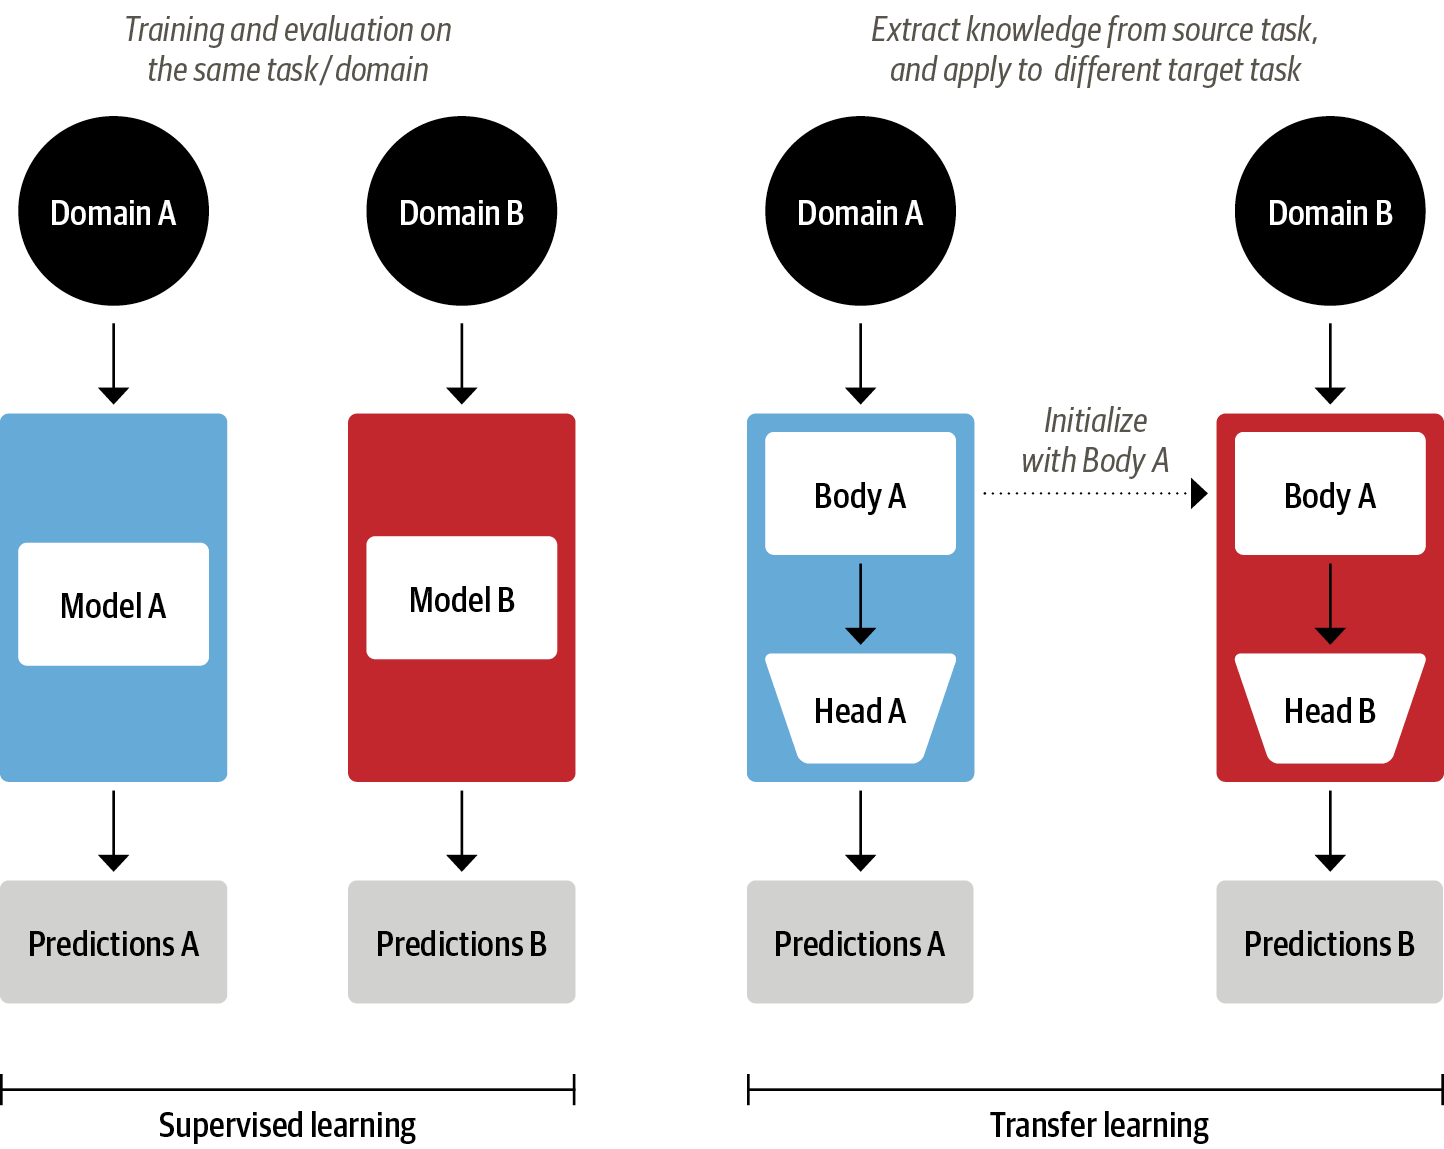
</figure>



En récupérant les modèles de `SpaCy`, on a déjà réalisé en partie un telle démarche mais la librairie `transformers` permet l'adaptation d'un grand nombre de modèles issus de frameworks a priori incompatibles (`Pytorch`, `Tensorflow` et `JAX`). On peut alors prolonger l'entrainement de modèles prévus initialement dans des architectures différentes avec une seule API.

Cette sectionvise à illustrer les deux dimensions de cette librairie en commençant par un tour d'horizon inspiré par [le cours en ligne de cette libriairie](https://huggingface.co/learn/nlp-course/) et Tunstall et al. (2022) et [le Github de ce livre](https://github.com/nlp-with-transformers). Un entrainement est ensuite présenté sur le corpus des avis allociné issu de Blard (2020).

## 2.1 Tour d'horizon des applications NLP des Transformers

In [ ]:
pip install transformers
pip install sentencepiece  # utilisé implicitement pour la tokénisation des "slow tokenizers"
# Depuis le passage à Keras 3, il faut installer tf-keras et spécifier TF_USE_LEGACY_KERAS = 1 pour utiliser Keras 2 (en avril 2024) : https://discuss.huggingface.co/t/pretrain-model-not-accepting-optimizer/76209/6
pip install tf-keras
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

La librairie dispose d'un module `pipeline` qui permet d'appliquer directement des modèles préentrainés à des tâches spécifiques ([et non uniquement pour le NLP](https://huggingface.co/docs/transformers/main_classes/pipelines)). On se limite ici aux plus classiques ([voire la section des tâches disponibles avec cette librairie](https://huggingface.co/tasks/))

### 2.1.1 La classification de documents

Le premier pipeline que l'on peut présenter est l'analyse de sentiments qui est classée [parmi les tâches de '*classification de texte*'](https://huggingface.co/tasks/text-classification) :

In [ ]:
from transformers import pipeline

In [ ]:
classifier = pipeline("text-classification")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Si l'on ne spécifie pas davantage le modèle, la librairie télécharge par défault depuis son hub le modèle Distilbert pour l'analyse de sentiment en anglais (`distilbert-base-uncased-finetuned-sst-2-english`). Si c'est pertinent, on peut alors directement appliquer le classifieur à un exemple et obtenir le label inféré ainsi qu'un score qui indique le degré de confiance dans la prédiction :



In [ ]:
classifier('Tranformers are great !')

[{'label': 'POSITIVE', 'score': 0.9998650550842285}]

On peut cependant spécifier le modèle que l'on souhaite télécharger (à condition qu'il soit adapté à la tâche visée). Par exemple, on peut trouver [dans la section 'models' du site](https://huggingface.co/models), en cliquant sur les onglets `Text classification` et `French`, le modèle `nlptown/bert-base-multilingual-uncased-sentiment` qui est le plus téléchargé et est directement disponible dans l'objet `pipeline` :


In [ ]:
classifier = pipeline("text-classification", model = "nlptown/bert-base-multilingual-uncased-sentiment")

classifier("Tranformers c'est  vraiment super !")

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[{'label': '5 stars', 'score': 0.8171705007553101}]


On peut également trouver le modèle `"tblard/tf-allocine"` qui est la version mise en ligne de l'analyseur d'avis de films de Blard (2020). Cependant, il ne peut pas être directement invoqué dans l'objet pipeline. Il faut expliciter un tokenizer (l'option AutoTokenizer est possible ici) et la version pour Tensorflow du AutoModel :

In [ ]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("tblard/tf-allocine", max_length=512, truncation=True, padding=True, return_tensors="tf")

model = TFAutoModelForSequenceClassification.from_pretrained("tblard/tf-allocine")

classifier = pipeline("sentiment-analysis", tokenizer = tokenizer, model = model)

classifier("Tranformers c'est vraiment super !")


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/445M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFCamembertForSequenceClassification.

All the layers of TFCamembertForSequenceClassification were initialized from the model checkpoint at tblard/tf-allocine.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFCamembertForSequenceClassification for predictions without further training.


[{'label': 'POSITIVE', 'score': 0.9955130219459534}]

La taille du vocabulaire de Camembert et de  32 005 mots (la taille approximative du français courant) :

In [ ]:
tokenizer.vocab_size

32005

La description du modèle montre :
- que tous les paramètres sont entrainables, plus de 110 millions ...
- qu'il y a un Roberta main layer et un classifier

In [ ]:
model.summary()

Model: "tf_camembert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 roberta (TFCamembertMainLa  multiple                  110031360 
 yer)                                                            
                                                                 
 classifier (TFCamembertCla  multiple                  592130    
 ssificationHead)                                                
                                                                 
Total params: 110623490 (422.00 MB)
Trainable params: 110623490 (422.00 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


On peut alors charger sur l'espace de travail le fichier test.jsonl en sélectionnant `Fichier` dans la barre latérale gauche et `Import`. On peut alors évaluer le résultat de l'entrainement réalisé dans Blard (2020).

In [ ]:
with open('/content/test.jsonl', 'r', encoding='utf-8') as json_file:
    test_list = list(json_file)

In [ ]:
import json
import pandas as pd
import numpy as np

df_allocine_test = pd.DataFrame({'id': [json.loads(test_list[r])['film-url'] for r in range(len(test_list))],
                         'texts' : [json.loads(test_list[r])['review'] for r in range(len(test_list))],
                        'label': [json.loads(test_list[r])['polarity'] for r in range(len(test_list))]
                         })

df_allocine_test.head()

,id,texts,label
0,http://www.allocine.fr/film/fichefilm-25385/cr...,"Magnifique épopée, une belle histoire, touchan...",1
1,http://www.allocine.fr/film/fichefilm-1954/cri...,Je n'ai pas aimé mais pourtant je lui mets 2 é...,0
2,http://www.allocine.fr/film/fichefilm-135523/c...,Un dessin animé qui brille par sa féerie et se...,1
3,http://www.allocine.fr/film/fichefilm-61514/cr...,"Si c'est là le renouveau du cinéma français, c...",0
4,http://www.allocine.fr/film/fichefilm-260395/c...,Et pourtant on s’en Doutait !Second volet très...,0


Il faut cependant être attentif à la taille des textes soumis avec les modèles Tranformers : ils peuvent rapidement déconnecter l'environnement Gogle Colab. On peut donc commencer par un MODE test (il faudra ensuite reprendre à l'étape précédente) :

In [ ]:
MODE = 'reel'

MODE = 'test'

if MODE == 'test':
    frac=0.01
    df_allocine_test = df_allocine_test.sample(frac=frac)


X_test=np.array(df_allocine_test['texts'])

y_test=np.array(df_allocine_test['label'])

In [ ]:
len(y_test)

200

On doit ensuite passer par des découpage de X_test avec l'option `batch_size` de la méthode `predict` (ici par 100 textes). Si le mode test passe, le réel implique 13 minutes environ dans le mode d'exécution GPU standard (1 minute avec la version PRO+ qui utilise des GPU NVIDIA A100 au lieu de TESLA T4) :

In [ ]:
encoded = tokenizer(X_test.tolist(), max_length=512, truncation=True, padding=True, return_tensors="tf")

y_pred = model.predict(dict(encoded),batch_size = 100)


2/2 [==============================] - 17s 12ms/step


Les prédictions sont sous forme de logits (plutôt que des probabilités) auxquels on accède par index. Dans ce modèles, deux classes sont possibles :

In [ ]:
y_pred[0].shape

(200, 2)

In [ ]:
y_pred[0][0]

array([-3.24261  ,  3.2275743], dtype=float32)

Le plus grand des deux nombres est la classe prédite par le modèle donc on crée le vecteur des prédictions `y_pred_test` en utilisant la fonction `np.argmax` :

In [ ]:
y_pred_test = np.argmax(y_pred[0], axis=1)

L'évaluation du modèle sur le test set indique un score F1 macro de 0.97 en MODE réel :

In [ ]:
from sklearn import metrics
print(metrics.classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        99
           1       0.98      1.00      0.99       101

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



### 2.1.2 La classification de token

Un deuxième pipeline de cette librairie intéressant à présenter est celui de la détection d'entité nommée (NER) qui est intégré dans l'ensemble des tâches de [classification de token](https://huggingface.co/tasks/token-classification), avec notamment le POS tagging

In [ ]:
classifier = pipeline("ner")
classifier("Hello I'm Arnold and I live in Paris.")

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision f2482bf (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

[{'entity': 'I-PER',
  'score': 0.99846566,
  'index': 5,
  'word': 'Arnold',
  'start': 10,
  'end': 16},
 {'entity': 'I-LOC',
  'score': 0.9991716,
  'index': 10,
  'word': 'Paris',
  'start': 31,
  'end': 36}]

C'est cette fois le modèle `dbmdz/bert-large-cased-finetuned-conll03-english` qui est téléchargé par défaut, mais on peut rechercher un modèle pour une langue donnée sur le site. Le modèle en français le plus téléchargé est `Jean-Baptiste/camembert-ner` (entrainé avec Pytorch et disponible dans le module `pipeline`) qui rapporte des scores F1 très élevés : PER = 0.9483, ORG = 0.8181, LOC = 0.8955, MISC = 0.8146. Plusieurs modèles multilingues sont également disponibles.

In [ ]:
classifier = pipeline("ner", model = 'Jean-Baptiste/camembert-ner')
classifier("Hello je suis Arnold et je vis à Paris.")

config.json:   0%|          | 0.00/892 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

[{'entity': 'I-PER',
  'score': 0.9036888,
  'index': 4,
  'word': '▁Arn',
  'start': 13,
  'end': 17},
 {'entity': 'I-PER',
  'score': 0.8916999,
  'index': 5,
  'word': 'old',
  'start': 17,
  'end': 20},
 {'entity': 'I-LOC',
  'score': 0.9982602,
  'index': 10,
  'word': '▁Paris',
  'start': 32,
  'end': 38}]

Pour maintenir une sortie plus lisible il peut être utile de spécifier la stratégie d'agrégation pour que les tokens infra-mots soient regroupés (sauf si on veut entrainer ensuite un autre algorithme) :

In [ ]:
classifier = pipeline("ner", model = 'Jean-Baptiste/camembert-ner', aggregation_strategy = "simple")
classifier("Hello je suis Arnold et je vis à Paris.")

[{'entity_group': 'PER',
  'score': 0.89769435,
  'word': 'Arnold',
  'start': 13,
  'end': 20},
 {'entity_group': 'LOC',
  'score': 0.9982602,
  'word': 'Paris',
  'start': 32,
  'end': 38}]

### 2.1.3 Question-answering

Parmi les classification de documents, la tâche Question Natural Language Inference (QNLI) s'intéresse à déterminer si un texte contient la réponse à une question. Si on souhaite obtenir la réponse à une question, lorsqu'elle est a priori dans le texte, on applique un algorithme de QA.

[Dans la librairie transformers](https://huggingface.co/tasks/question-answering), différentes variantes de cette tâche sont disponibles :
- extractive : losqu'un contexte est disponible (texte, table, html) pour l'algorithme qui doit y détecter les passages pertinents ;
- ouverte et générative :  un contexte est fourni et l'algorithme doit générer une réponse pertinente sur cette base ;
- fermée et générative : aucun contexte n'est fourni et l'algorithme doit générer une réponse pertinente.

Le score d'évaluation classique est alors le F1 pour la première variante ou l'exact match (basés sur le span des caractères renvoyés).

In [ ]:
qa_model = pipeline("question-answering")
question = "Where do I live?"
context = "My name is Arnold and I live in Paris."

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 626af31 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [ ]:
qa_model(question = question, context = context)

{'score': 0.9826070070266724, 'start': 32, 'end': 37, 'answer': 'Paris'}

Pour davantage d'information sur les méthodes exploitées pour entrainer de tels modèles, on peut regarder le [site de référence SQUAD 2](https://rajpurkar.github.io/SQuAD-explorer/) qui met à disposition des datasets pour l'entrainement, présente le score du même nom pour les différentes variantes de cette tâche et tient l'historique des meilleures solutions existantes.

Pour le français, [Etalab ppropose un modèle de QA](https://www.data.gouv.fr/fr/reuses/modele-de-questions-reponses-francophone/), `etalab-ia/camembert-base-squadFR-fquad-piaf`, disponible directement  dans le module `pipeline` :

In [ ]:
qa_model = pipeline("question-answering", model='etalab-ia/camembert-base-squadFR-fquad-piaf')
question = "Où est ce que je vis ?"
context = "Hello je suis Arnold et je vis à Paris."

config.json:   0%|          | 0.00/515 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

In [ ]:
qa_model(question = question, context = context)

{'score': 0.9292072057723999, 'start': 32, 'end': 39, 'answer': ' Paris.'}

Parmi les variantes intéressante de cette tâche de QA, on peut également citer le [Table Question Answering](https://huggingface.co/tasks/table-question-answering) pour lequel le modèle `google/tapas-base-finetuned-wtq`est le plus téléchargé à ce jour. Il n'y en a pas de disponible en français pour le moment.

### 2.1.4 Traduction

La traduction est l'une des première tâche visée par les modèles Transformers qui sont pensés comme des encodeurs-décodeurs.

A ce jour, c'est le modèle t5-base qui est téléchargé par défaut avec le `pipeline` associé :

In [ ]:
from transformers import pipeline
en_fr_translator = pipeline("translation_en_to_fr")
en_fr_translator("How old are you?")

No model was supplied, defaulted to google-t5/t5-base and revision 686f1db (https://huggingface.co/google-t5/t5-base).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/models/t5/tokenization_t5_fast.py:171: FutureWarning: This tokenizer was incorrectly instantiated with a model max length of 512 which will be corrected in Transformers v5.
For now, this behavior is kept to avoid breaking backwards compatibility when padding/encoding with `truncation is True`.
- Be aware that you SHOULD NOT rely on google-t5/t5-base automatically truncating your input to 512 when padding/encoding.
- If you want to encode/pad to sequences longer than 512 you can either instantiate this tokenizer with `model_max_length` or pass `max_length` when encoding/padding.
- To avoid this warning, please instantiate this tokenizer with `model_max_length` set to your preferred value.
  warnings.warn(


[{'translation_text': ' quel âge êtes-vous?'}]

Cependant, il est fréquent de plutôt utiliser les modèles produit par l'Université d'Helsinki qui en propose plus de 1400 modèles classés en paires de langues, par exemple `Helsinki-NLP/opus-mt-en-fr` :

In [ ]:
translator = pipeline("translation", model="Helsinki-NLP/opus-mt-en-fr")
translator("How old are you?")

config.json:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/301M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.34M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/models/marian/tokenization_marian.py:197: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


[{'translation_text': 'Quel âge avez-vous ?'}]

En terme de score, l'évaluation des modèles est réalisée avec les scores BLEU et SACREBLEU [présentés dans cette vidéo du cours de Hugging Face](https://youtu.be/M05L1DhFqcw).

### 2.1.5 Le résumé de texte



Le modèle téléchargé par défaut est `sshleifer/distilbart-cnn-12-6` pour l'anglais. Il s'agit assez logiquement d'un modèle seq2seq, c'est-à-dire encodeur-décodeur.


In [ ]:
classifier = pipeline("summarization")
classifier('''Paris is the capital and most populous city of France, with an estimated population of 2,175,601 residents as of 2018, in an area of more than 105 square kilometres (41 square miles). The City of Paris is the centre and seat of government of the region and province of Île-de-France, or Paris Region, which has an estimated population of 12,174,880, or about 18 percent of the population of France as of 2017.''')


No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Your max_length is set to 142, but your input_length is only 96. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=48)


[{'summary_text': ' Paris is the capital and most populous city of France, with an estimated population of 2,175,601 residents as of 2018 . The city is the centre and seat of government of the region and province of Île-de-France, or Paris Region . Paris Region has an estimated 18 percent of the population of France as of 2017 .'}]

Le score utilisé pour évaluer la qualité du résumé est le score ROUGE [présenté dans cette vidéo du cours de Hugging Face](https://youtu.be/TMshhnrEXlg).

### 2.1.6 Génération de texte

Pour la génération de texte, le modèle téléchargé par défaut est `gpt2` :

In [ ]:
from transformers import pipeline
generator = pipeline('text-generation')
generator("Hello, I'm a language model", max_length = 30, num_return_sequences=3)

No model was supplied, defaulted to openai-community/gpt2 and revision 6c0e608 (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': "Hello, I'm a language model that needs lots of attention. A lot of people have used languages such as C, Java, HTML and Perl before"},
 {'generated_text': "Hello, I'm a language model! You may have noticed that I use the prefix I-E-. There are a few other language models of languages"},
 {'generated_text': "Hello, I'm a language model, I use a whole bunch of the tools you're using that are built around that. So, you can even"}]

Les modèles de génération disposent même d'un `pipeline` supplémentaire `text2text-generation`qui prend une phrase en entrée incluant une tâche et qui retourne la tâche accomplie. Cela est fait par défaut avec le modèle `t5-base` :

In [ ]:
text2text_generator = pipeline("text2text-generation")
text2text_generator("question: What is 42 ? context: 42 is the answer to life, the universe and everything")

No model was supplied, defaulted to google-t5/t5-base and revision 686f1db (https://huggingface.co/google-t5/t5-base).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.10/dist-packages/transformers/generation/utils.py:1178: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


[{'generated_text': 'the answer to life, the universe and everything'}]

In [ ]:

text2text_generator("translate from English to French: I'm very happy")

[{'generated_text': 'Je suis très heureux'}]

Le modèle `bigscience/T0` est indiqué par Hugging Face comme étant à ce jour le plus robuste et flexible pour cette tâche.. Moyennant 44Go de téléchargement :

In [ ]:
text2text_generator = pipeline("text2text-generation", model = "bigscience/T0")

config.json:   0%|          | 0.00/633 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/44.5G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.86k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [ ]:
text2text_generator("Is the word 'table' used in the same meaning in the two previous sentences? Sentence A: you can leave the books on the table over there. Sentence B: the tables in this book are very hard to read." )

[{'generated_text': 'No'}]

In [ ]:
text2text_generator("A is the son's of B's brother. What is the family relationship between A and B?")

[{'generated_text': 'brother and son'}]

In [ ]:
text2text_generator("Is this review positive or negative? Review: this is the best cast iron skillet you will ever buy")

[{'generated_text': 'Positive'}]

In [ ]:
text2text_generator("Reorder the words in this sentence: justin and name bieber years is my am I 27 old.")

[{'generated_text': "bieber justin 's name is my name i am 27 years old"}]

## 2.2 Entrainement d'un classifieur de sentiment

### 2.2.1 Montage du drive et import des données

Pour réaliser l'entrainement on va plutôt charger les trois parties de la base de données dans Drive et y connecter Google Colab.

In [ ]:
from google.colab import drive

drive.mount('/gdrive')

import json
import numpy as np
import pandas as pd
import tensorflow as tf
assert tf.__version__ >= "2.0"
from sklearn import metrics

DATA_DIR = '/gdrive/MyDrive/data/allocine/'
OUT_DIR =  '/gdrive/MyDrive/out/allocine_form_doc/'

Mounted at /gdrive


In [ ]:
with open(DATA_DIR + 'train.jsonl', 'r', encoding='utf-8') as json_file:
    train_list = list(json_file)

with open(DATA_DIR + 'val.jsonl', 'r', encoding='utf-8') as json_file:
    val_list = list(json_file)

with open(DATA_DIR + 'test.jsonl', 'r', encoding='utf-8') as json_file:
    test_list = list(json_file)

df_train = pd.DataFrame({'id': [json.loads(train_list[r])['film-url'] for r in range(len(train_list))],
                         'texts' : [json.loads(train_list[r])['review'] for r in range(len(train_list))],
                        'label': [json.loads(train_list[r])['polarity'] for r in range(len(train_list))]
                         })


df_valid = pd.DataFrame({'id': [json.loads(val_list[r])['film-url'] for r in range(len(val_list))],
                          'texts' : [json.loads(val_list[r])['review'] for r in range(len(val_list))],
                          'label': [json.loads(val_list[r])['polarity'] for r in range(len(val_list))]
                         })

df_test = pd.DataFrame({'id': [json.loads(test_list[r])['film-url'] for r in range(len(test_list))],
                         'texts' : [json.loads(test_list[r])['review'] for r in range(len(test_list))],
                        'label': [json.loads(test_list[r])['polarity'] for r in range(len(test_list))]
                         })

Il n'y a normalement pas ici de risque de saturer Google Colab, mais l'entrainement peut être long donc on définit un MODE test :

In [ ]:

MODE = 'all'
MODE = 'test'

if MODE == 'test':
    frac=0.01
    df_train = df_train.sample(frac=frac)
    df_valid = df_valid.sample(frac=frac)
    df_test = df_test.sample(frac=frac)

train_reviews = np.array(df_train["texts"])
val_reviews = np.array(df_valid["texts"])
test_reviews = np.array(df_test["texts"])

y_train = df_train['label']
y_val = df_valid['label']
y_test = df_test['label']

In [ ]:
len(y_test)

200

### 2.2.2 Définition des briques du modèle

In [ ]:
from transformers import CamembertTokenizer, TFCamembertForSequenceClassification

model_name = "jplu/tf-camembert-base"

tokenizer = CamembertTokenizer.from_pretrained(model_name)

model = TFCamembertForSequenceClassification.from_pretrained(model_name)

opt = tf.keras.optimizers.Adam(learning_rate=5e-6, epsilon=1e-08)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/545M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFCamembertForSequenceClassification.

Some layers of TFCamembertForSequenceClassification were not initialized from the model checkpoint at jplu/tf-camembert-base and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
encoded_train=dict(tokenizer(train_reviews.tolist(), max_length=512, padding=True, truncation=True, return_tensors="tf"))
encoded_val=dict(tokenizer(val_reviews.tolist(), max_length=512, padding=True, truncation=True, return_tensors="tf"))
encoded_test=dict(tokenizer(test_reviews.tolist(), max_length=512, padding=True, truncation=True, return_tensors="tf"))

### 2.2.3 Entrainement du modèle

Sur les avis, en considérant 1 600 observations dans le train on obtient 400 batchs si batch_size = 4. Sur l'ensemble des avis allocine, il y a 160 000 observations soit 40000 batchs.

**sans GPU : un seul epoch, 1% données allociné**
- au bout de  17 min, 53 % en accuracy et 58/400 en batch
- au bout de 1h 40 min, 61,07 % en accuracy et 363/400
- au final 2h, 62.6 % en accuracy sur le train et 91.5 % en validation

**en GPU : 1% données allociné**
- 1er epoch : 3 min 30,  72.2 %  en accuracy sur le train et 92.5 en validation
- 2nd epoch : 6 min 05,  94.18 %  train et 94.5 % en validation


**en GPU+ : 100% données allociné**
- 1er epoch : 35 min,  96.15 %  en accuracy sur le train et 97.19 en validation
- 2nd epoch : 33 min,  97.74 %  train et 97.33 % en validation


**Remarques:**
- Par défaut, tout nouvel entrainement repart des poids obtenus précédemments : il ne repart pas de zéro.
- il ne se sert de l'échantillon de validation qu'à la fin
- dans le notebook original, on voit que le meilleur modèle est réalisé avec 3 epochs

In [ ]:
NB_EPOCH = 2
history = model.fit(
    encoded_train, y_train,
    epochs=NB_EPOCH,
    batch_size=4,
    validation_data=(encoded_val, y_val),
    verbose=1,
)

Epoch 1/2


Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: for/else statement not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
400/400 [==============================] - 167s 230ms/step - loss: 0.4920 - accuracy: 0.8056 - val_loss: 0.2134 - val_accuracy: 0.9500
Epoch 2/2
400/400 [==============================] - 56s 139ms/step - loss: 0.2008 - accuracy: 0.9419 - val_loss: 0.1608 - val_accuracy: 0.9500


In [ ]:
scores_valid = model.predict(encoded_val)
y_pred_valid = np.argmax(scores_valid[0], axis=1)
valid_acc = metrics.classification_report(y_val, y_pred_valid)
print("Classification report :\n", valid_acc)

7/7 [==============================] - 10s 230ms/step
Classification report :
               precision    recall  f1-score   support

           0       0.96      0.94      0.95       101
           1       0.94      0.96      0.95        99

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



### 2.2.4 Sauvegarde et chargement du modèle entrainé

On peut spécifier un répertoire dans lequel seront stockés différents fichiers de sauvegarde du modèle qu'on vient d'entrainer. Pour la version large il faut compter environ 420 Mo :




In [ ]:
model.save_pretrained(OUT_DIR + 'allocine_model_'+ MODE)

La récupération se fait avec la méthode `.from_pretrained()` :



In [ ]:
model2 = TFCamembertForSequenceClassification.from_pretrained(OUT_DIR + 'allocine_model_test')
scores_valid = model2.predict(encoded_val)
y_pred_valid = np.argmax(scores_valid[0], axis=1)
valid_acc = metrics.classification_report(y_val, y_pred_valid)
print("Classification report :\n", valid_acc)

All model checkpoint layers were used when initializing TFCamembertForSequenceClassification.

All the layers of TFCamembertForSequenceClassification were initialized from the model checkpoint at /gdrive/MyDrive/out/allocine_form_doc/model_large.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFCamembertForSequenceClassification for predictions without further training.


7/7 [==============================] - 12s 231ms/step
Classification report :
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       101
           1       0.98      0.98      0.98        99

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



### 2.2.5 Evaluation du modèle

On retrouve des valeurs identiques à celles associées au modèle préentrainé `tblard/tf-allocine` :

In [ ]:
scores_test= model2.predict(encoded_test)
y_pred_test = np.argmax(scores_test[0], axis=1)
print(metrics.classification_report(y_test, y_pred_test))

7/7 [==============================] - 10s 211ms/step
              precision    recall  f1-score   support

           0       0.98      0.93      0.96       103
           1       0.93      0.98      0.95        97

    accuracy                           0.95       200
   macro avg       0.96      0.96      0.95       200
weighted avg       0.96      0.95      0.96       200



# 3. Références et sites

Blard T. (2020), "French sentiment analysis with BERT", (répertoire Github : https://github.com/TheophileBlard/french-sentiment-analysis-with-bert).

Github :
- Blard (2020) : https://github.com/TheophileBlard/french-sentiment-analysis-with-bert/
- Nlp with transformers : https://github.com/nlp-with-transformers
- Transformers : https://github.com/huggingface/transformers

Tunstall L., von Werra L., Wolf T. (2022), "Natural Language Processing with Transformers", Ed. O'Reilly.

